In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [21]:
import torch
from torchvision.transforms import transforms as T
from torchvision.datasets import OxfordIIITPet

In [22]:
dataset = OxfordIIITPet('/datasets', download = True, target_types = 'segmentation')

In [23]:
dataset[0]

(<PIL.Image.Image image mode=RGB size=394x500>,
 <PIL.PngImagePlugin.PngImageFile image mode=L size=394x500>)

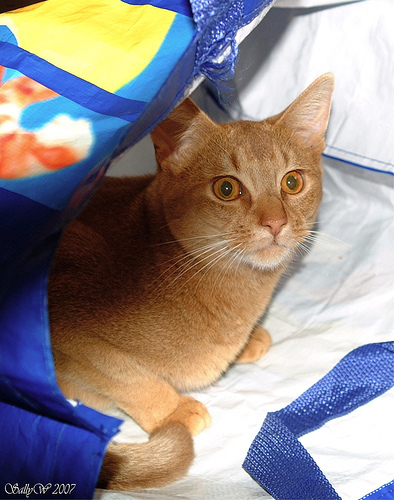

In [24]:
dataset[0][0]

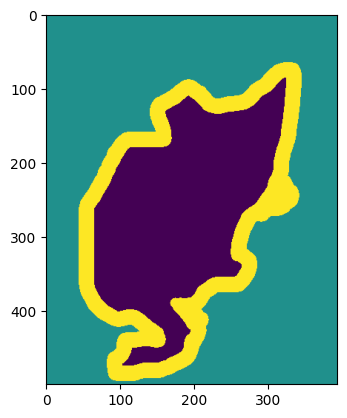

In [25]:
plt.imshow(dataset[0][1])

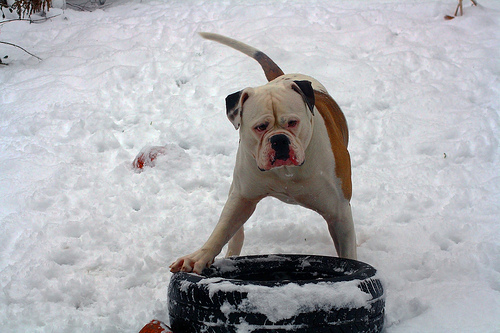

In [26]:
dataset[90][0]

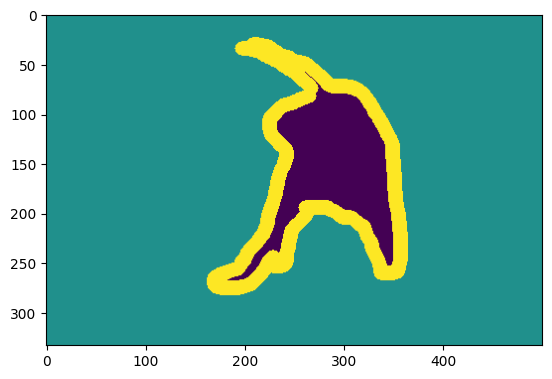

In [27]:
plt.imshow(dataset[90][1])

In [28]:
transform = T.Compose(
    [
        T.Resize((128, 128)),
        T.ToTensor()
    ]
)

target_transform = T.Compose(
    [
        T.Resize((128, 128)),
        T.PILToTensor(),
        T.Lambda(lambda x: (x - 1).long())
    ]
)

train_dataset = OxfordIIITPet('/datasets', transform = transform, target_transform = target_transform, target_types = 'segmentation')
test_dataset = OxfordIIITPet('/datasets', transform = transform, split = 'test', target_transform = target_transform, target_types = 'segmentation')

In [29]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_dataset, batch_size = 64, shuffle = True, num_workers = 4, pin_memory = True)
test_loader = DataLoader(test_dataset, batch_size = 64, shuffle = False, num_workers = 4, pin_memory = True)

In [30]:
from tqdm import tqdm

def train(model):
    model.train()

    total_loss = 0
    total = 0
    correct = 0

    for x, y in tqdm(train_loader, desc = 'train'):
        bs = y.size(0)
    
        x, y = x.to(device), y.squeeze(1).to(device)
    
        optimizer.zero_grad()
        
        output = model(x)
        
        loss = loss_fn(output.reshape(bs, 3, -1), y.reshape(bs, -1))
        
        total_loss += loss.item()
        
        loss.backward()
        
        optimizer.step()

        _, y_pred = output.max(dim = 1)
        total += y.size(0) * y.size(1) * y.size(2)
        correct += (y_pred == y).sum().item()
    total_loss /= len(train_loader)
    accuracy = correct / total
    return total_loss, accuracy

In [31]:
@torch.inference_mode()
def evaluate(model, loader) -> tuple[float, float]:
    model.eval()

    total_loss = 0
    total = 0
    correct = 0

    for x, y in tqdm(loader, desc = 'test'):
        bs = y.size(0)

        x, y = x.to(device), y.squeeze(1).to(device)
        
        output = model(x)
        loss = loss_fn(output.reshape(bs, 3, -1), y.reshape(bs, -1))
        total_loss += loss.item()
        
        _, y_pred = output.max(dim = 1)
        total += y.size(0) * y.size(1) * y.size(2)
        correct += (y_pred == y).sum().item()

    total_loss /= len(loader)
    accuracy = correct / total
    return total_loss, accuracy

In [32]:
def plot_stats(
    train_loss : list[float],
    test_loss : list[float],
    train_accuracy : list[float],
    test_accuracy : list[float],
    title
):
    plt.figure(figsize = (16, 10))
    plt.title(title + ' loss')
    plt.plot(train_loss, label = 'Train loss')
    plt.plot(test_loss, label = 'Test loss')
    plt.legend()
    plt.grid()
    plt.show()

    plt.figure(figsize = (16, 10))
    plt.title(title + ' accuracy')
    plt.plot(train_accuracy, label = 'Train accuracy')
    plt.plot(test_accuracy, label = 'Test accuracy')
    plt.legend()
    plt.grid()
    plt.show()


In [33]:
from PIL import Image
@torch.inference_mode()
def visualize(model, batch):
    model.eval()

    xs, ys = batch
    to_pil = T.ToPILImage()

    for i, (x, y) in enumerate(zip(xs, ys)):
        prediction = model(x.unsqueeze(0).cuda()).squeeze(0).max(dim = 0)[1]

        fig, ax = plt.subplots(1, 3, figsize = (16, 10), facecolor = 'white')

        ax[0].imshow(to_pil(x))
        ax[1].imshow(to_pil(y.to(torch.uint8)))
        ax[2].imshow(to_pil(prediction.to(torch.uint8)))

        ax[0].axis('off')
        ax[1].axis('off')
        ax[2].axis('off')

        ax[0].set_title('Original image')
        ax[1].set_title('Segmentation mask')
        ax[2].set_title('Prediction')

        plt.subplots_adjust(wspace = 0, hspace = 0.1)
        plt.show()

        if i>=9:
            break

In [34]:
from IPython.display import clear_output
def whole_train_value_cycle(model, num_epochs, title):
    train_loss_history = []
    test_loss_history = []
    train_accuracy_history = []
    test_accuracy_history = []
    for epoch in range(num_epochs):
        train_loss, train_accuracy = train(model)
        test_loss, test_accuracy = evaluate(model, test_loader)

        train_loss_history.append(train_loss) 
        test_loss_history.append(test_loss)
        train_accuracy_history.append(train_accuracy) 
        test_accuracy_history.append(test_accuracy)

        clear_output()

        plot_stats(train_loss_history, test_loss_history,
                  train_accuracy_history, test_accuracy_history, title)

        visualize(model, next(iter(test_loader)))

In [62]:
import torch.nn as nn
def conv_plus_conv(in_channels: int, out_channels: int):
    return nn.Sequential(
        nn.Conv2d(
            in_channels, 
            out_channels,
            kernel_size = 3,
            stride = 1,
            padding = 1
        ),
        nn.BatchNorm2d(num_features = out_channels),
        nn.LeakyReLU(0.2),
        nn.Conv2d(
            out_channels, 
            out_channels,
            kernel_size = 3,
            stride = 1,
            padding = 1
        ),
        nn.BatchNorm2d(num_features = out_channels),
        nn.LeakyReLU(0.2),
    )

class UNET(nn.Module):

    def __init__(self):
        super().__init__()

        base_channels = 64

        self.down1 = conv_plus_conv(3, base_channels)
        self.down2 = conv_plus_conv(base_channels, base_channels * 2)
        self.down3 = conv_plus_conv(base_channels * 2, base_channels * 4)
        self.down4 = conv_plus_conv(base_channels * 4, base_channels * 8)

        self.up1 = conv_plus_conv(base_channels * 2, base_channels)
        self.up2 = conv_plus_conv(base_channels * 4, base_channels)
        self.up3 = conv_plus_conv(base_channels * 8, base_channels * 2)
        self.up4 = conv_plus_conv(base_channels * 16, base_channels * 4)

        self.bottleneck = conv_plus_conv(base_channels * 8, base_channels * 8)

        self.out = nn.Conv2d(in_channels = base_channels, out_channels = 3, kernel_size = 1)

        self.downsample = nn.MaxPool2d(kernel_size = 2, stride = 2)

    def forward(self, x):

        residual1 = self.down1(x) # (n, n, 3) -> (n, n, base)
        x = self.downsample(residual1) # (n, n, base) -> (n/2, n/2, base)

        residual2 = self.down2(x) # (n/2, n/2, base) -> (n/2, n/2, base * 2)
        x = self.downsample(residual2) # (n/2, n/2, base * 2) -> (n/4, n/4, base * 2)

        residual3 = self.down3(x) # (n/4, n/4, base * 2) -> (n/4, n/4, base * 4)
        x = self.downsample(residual3) # (n/4, n/4, base * 4) -> (n/8, n/8, base * 4)

        residual4 = self.down4(x) # (n/8, n/8, base * 4) -> (n/8, n/8, base * 8)
        x = self.downsample(residual4) # (n/8, n/8, base * 8) -> (n/16, n/16, base * 8)
        
        x = self.bottleneck(x) # (n/16, n/16, base * 8) -> (n/16, n/16, base * 8)

        x = nn.functional.interpolate(x, scale_factor = 2) # (n/4, n/4, base * 2) -> (n/2, n/2, base * 2)
        x = torch.cat((x, residual4), dim = 1) # (n/2, n/2, base * 2) -> (n/2, n/2, base * 4)
        x = self.up4(x) # (n/2, n/2, base * 4) -> (n/2, n/2, base)

        x = nn.functional.interpolate(x, scale_factor = 2) # (n/2, n/2, base) -> (n, n, base)
        x = torch.cat((x, residual3), dim = 1) # (n, n, base) -> (n, n, base * 2)
        x = self.up3(x) # (n, n, base * 2) -> (n, n, base)

        x = nn.functional.interpolate(x, scale_factor = 2) # (n/4, n/4, base * 2) -> (n/2, n/2, base * 2)
        x = torch.cat((x, residual2), dim = 1) # (n/2, n/2, base * 2) -> (n/2, n/2, base * 4)
        x = self.up2(x) # (n/2, n/2, base * 4) -> (n/2, n/2, base)

        x = nn.functional.interpolate(x, scale_factor = 2) # (n/2, n/2, base) -> (n, n, base)
        x = torch.cat((x, residual1), dim = 1) # (n, n, base) -> (n, n, base * 2)
        x = self.up1(x) # (n, n, base * 2) -> (n, n, base)

        x = self.out(x)

        return x
        

In [63]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(device)

loss_fn = nn.CrossEntropyLoss()

cuda:0


In [64]:
from torch.optim import Adam

model = UNET().to(device)

optimizer = Adam(model.parameters(), lr = 1e-3)


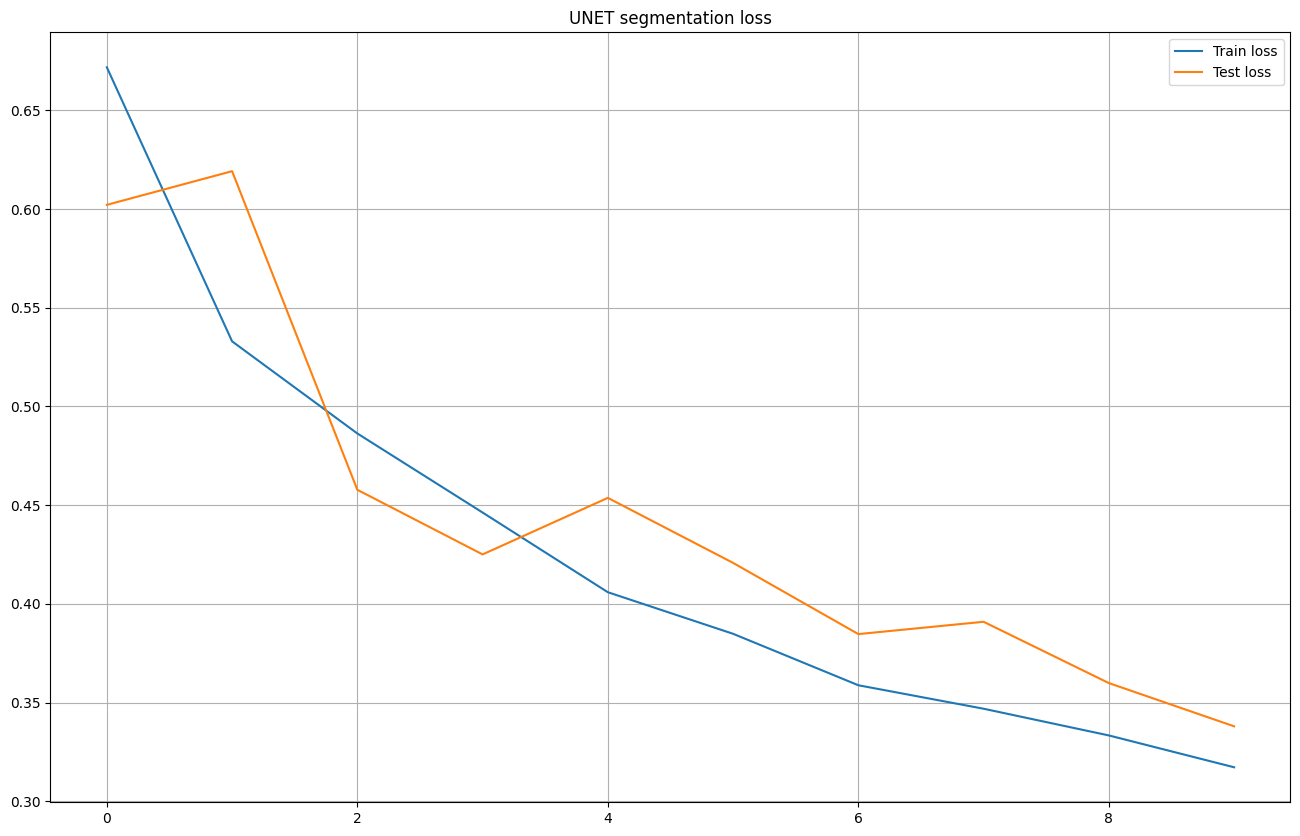

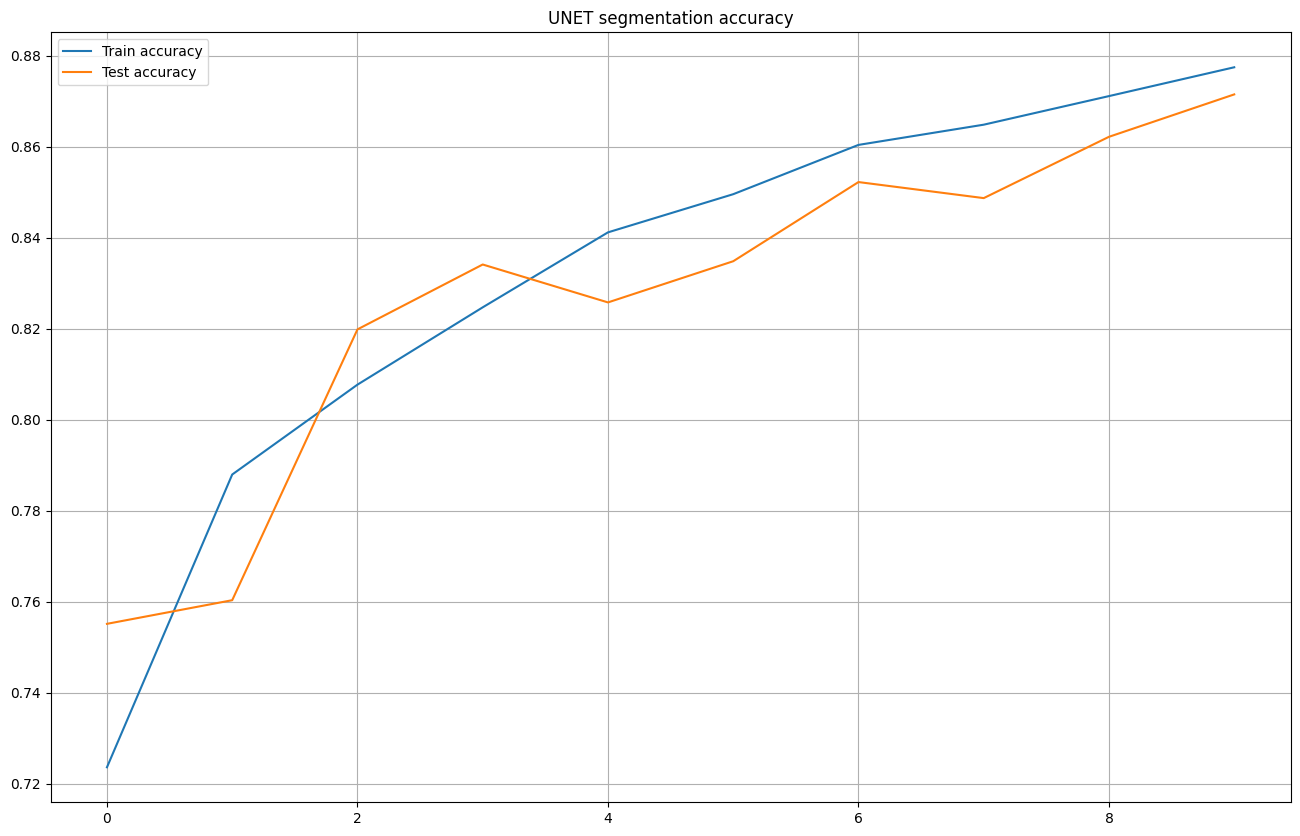

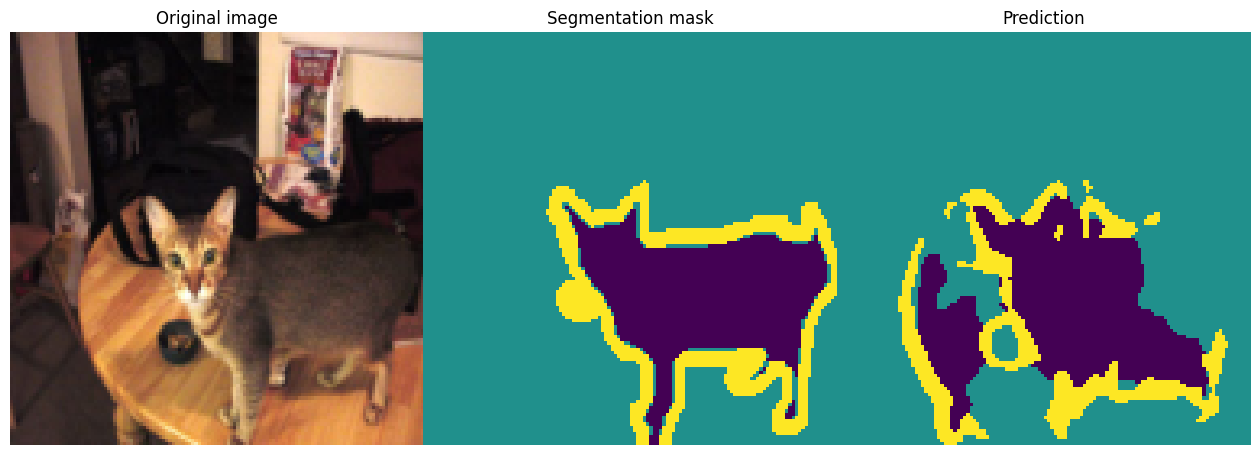

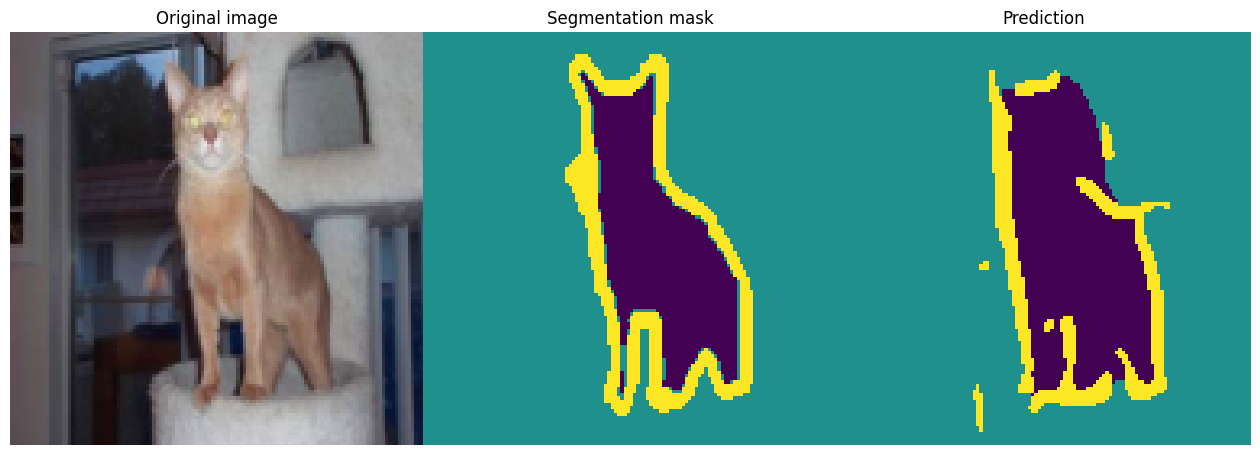

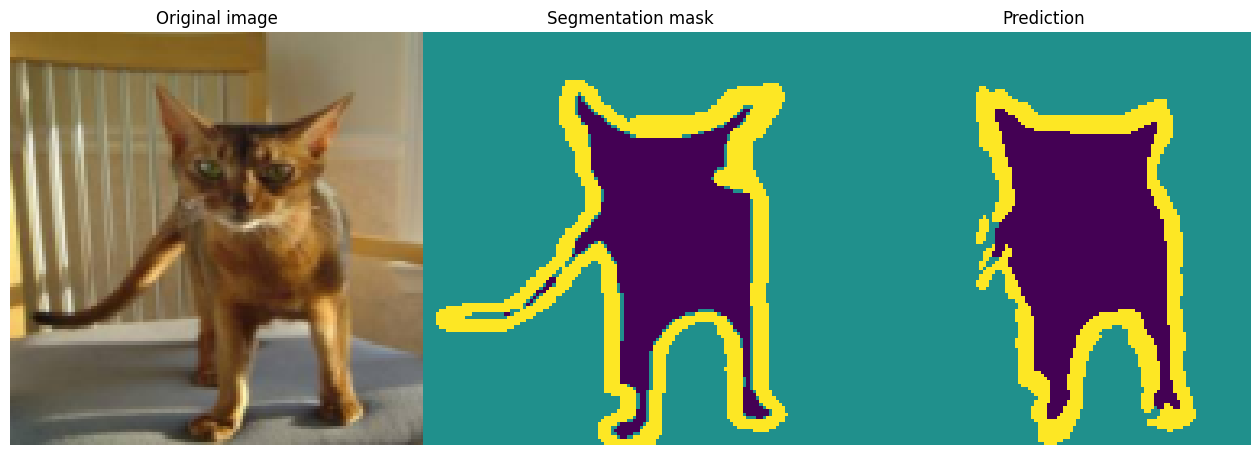

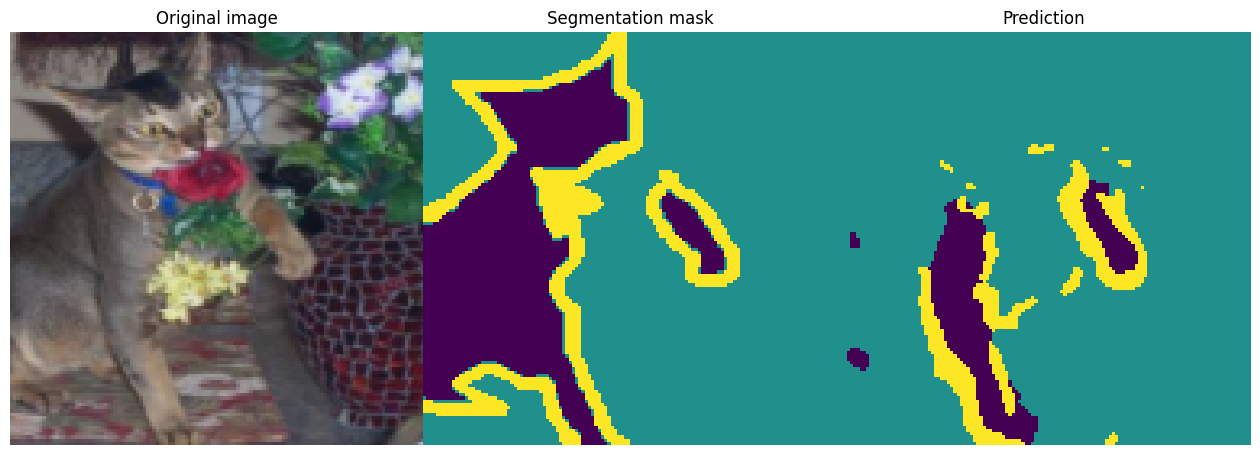

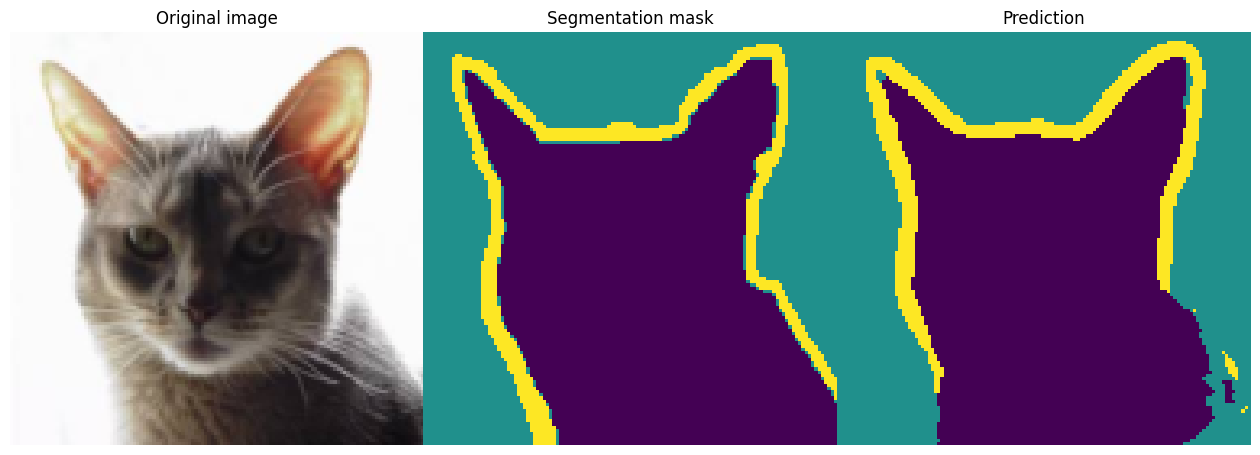

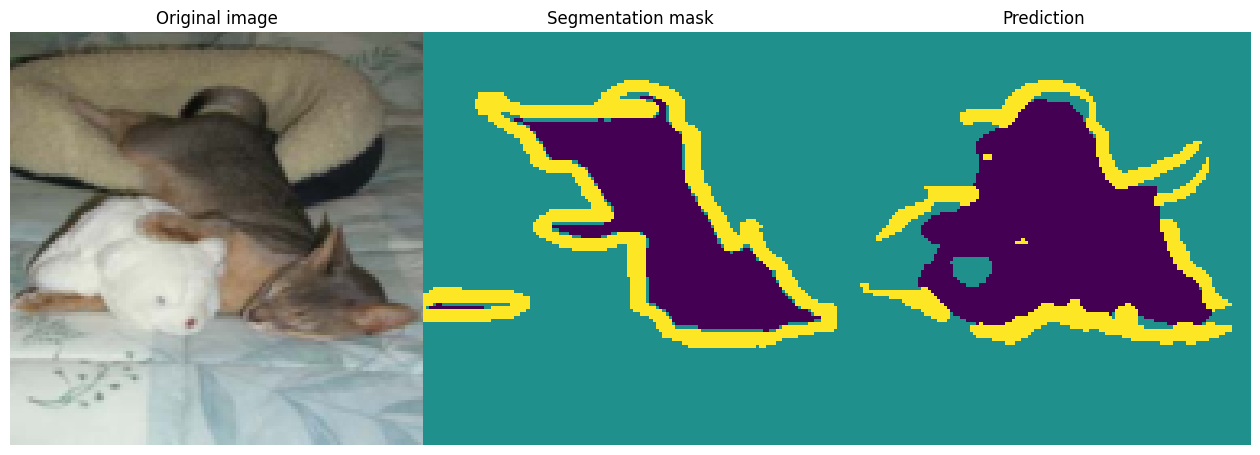

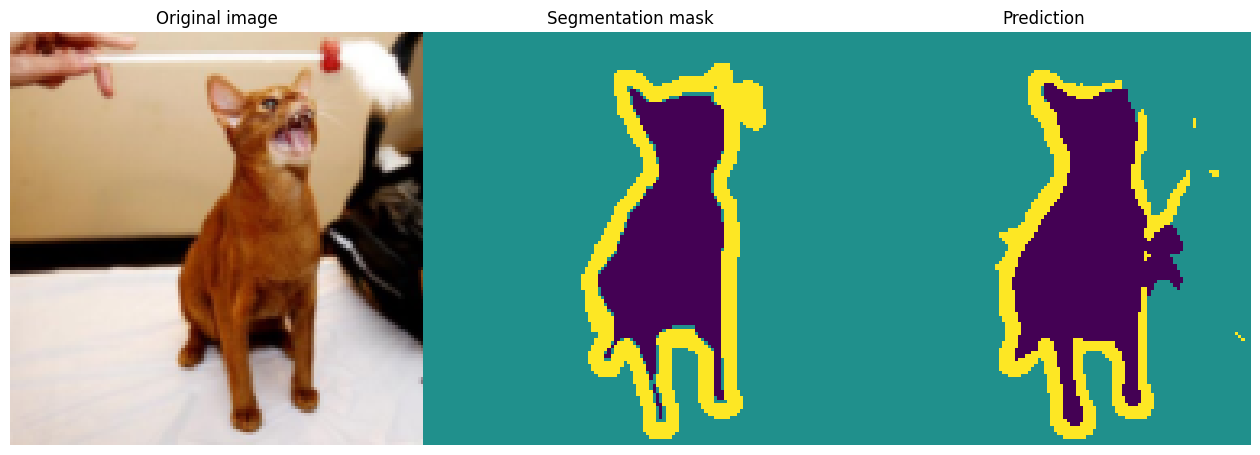

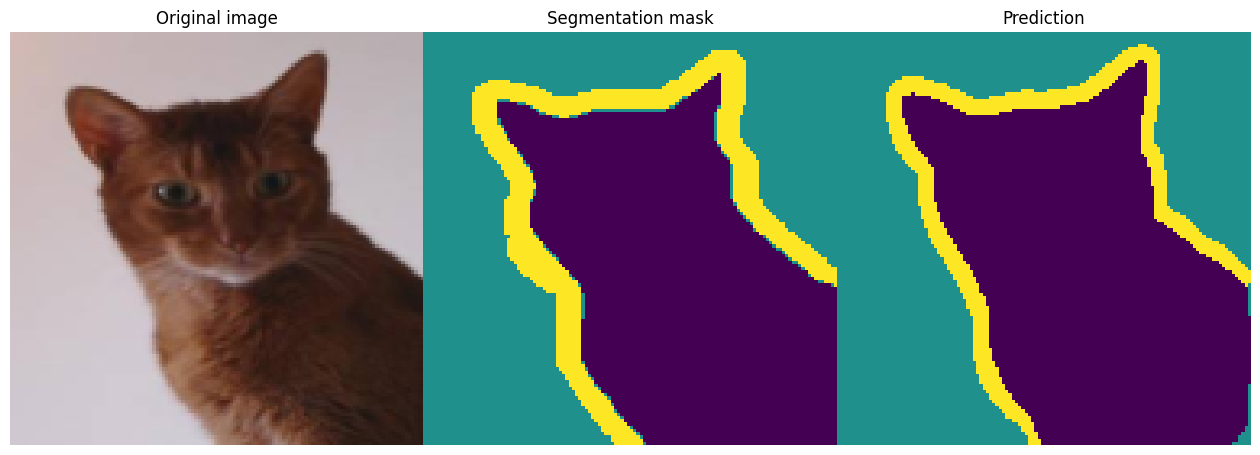

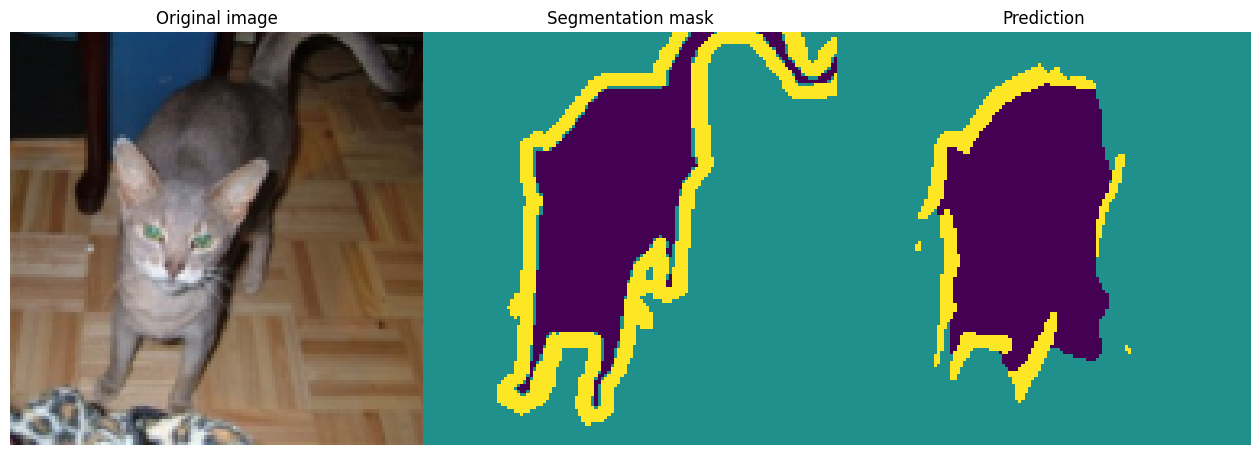

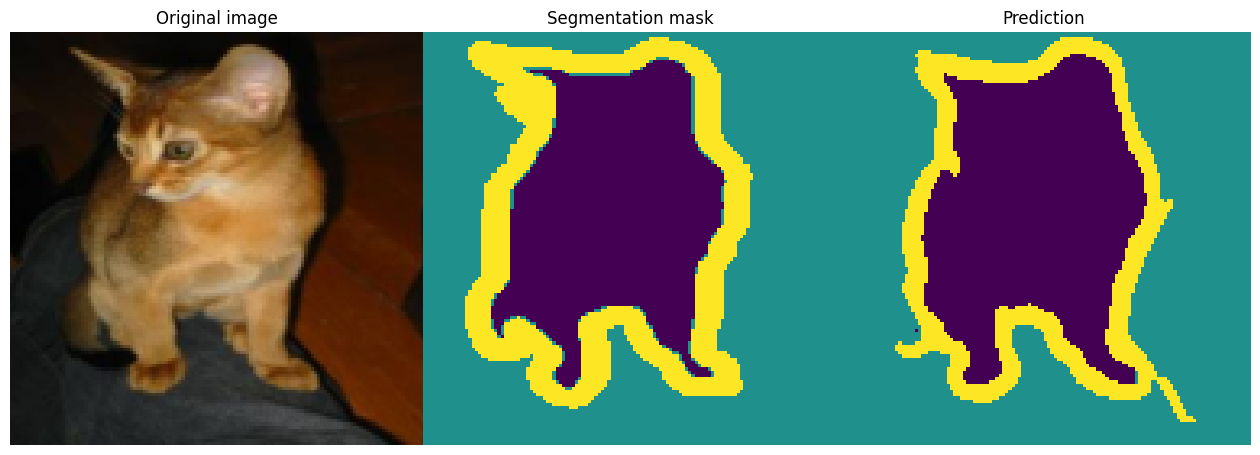

In [65]:
whole_train_value_cycle(model, 10, 'UNET segmentation')

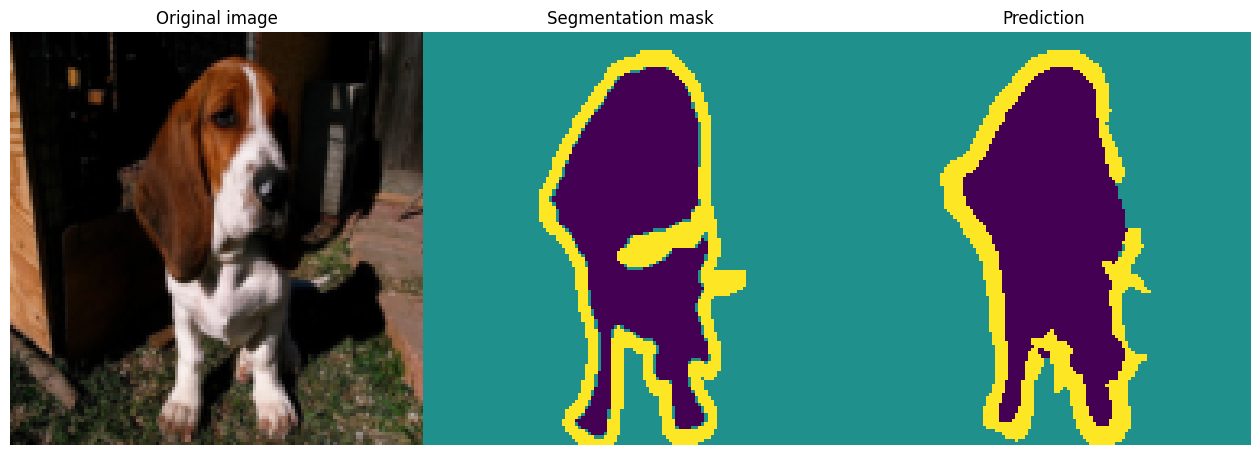

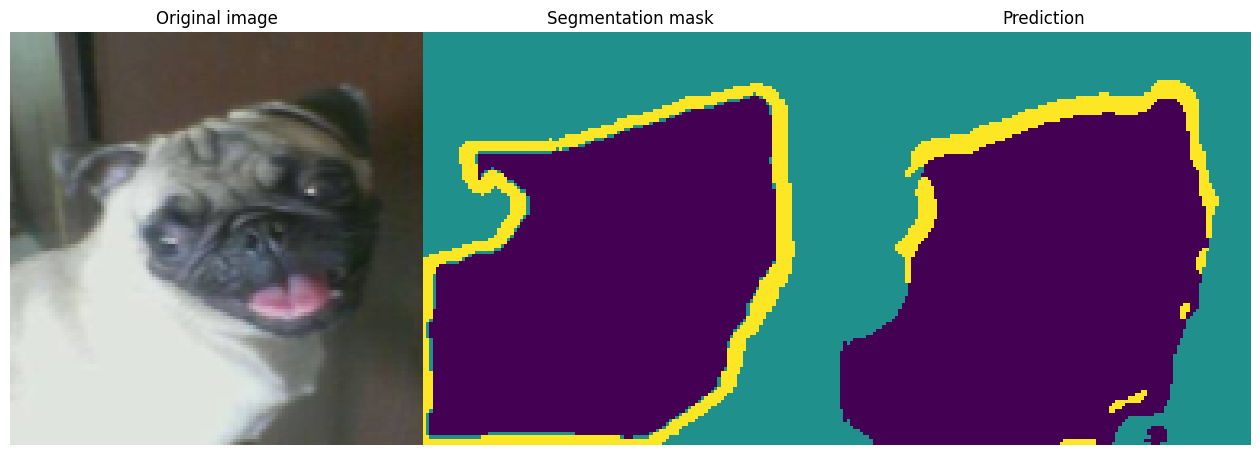

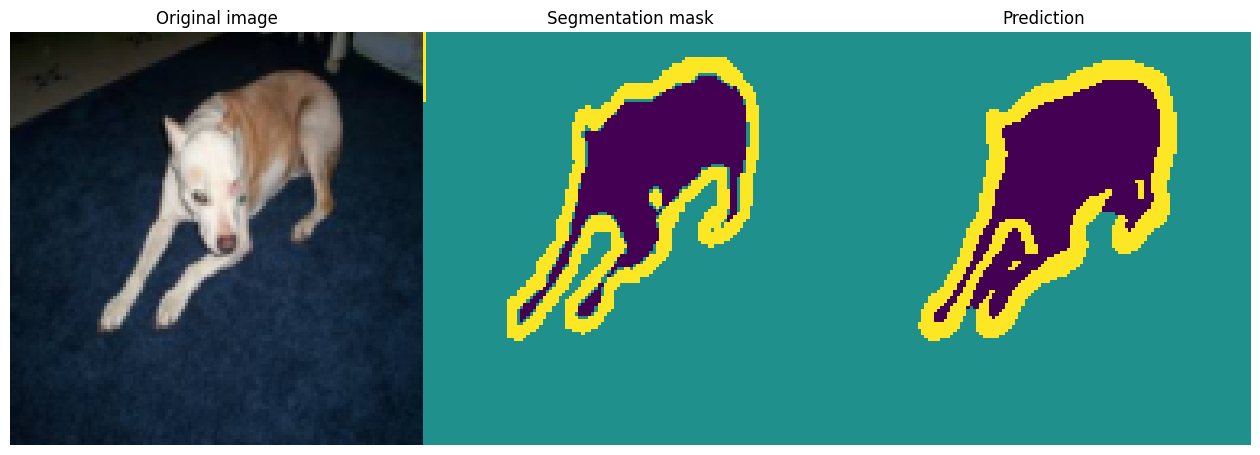

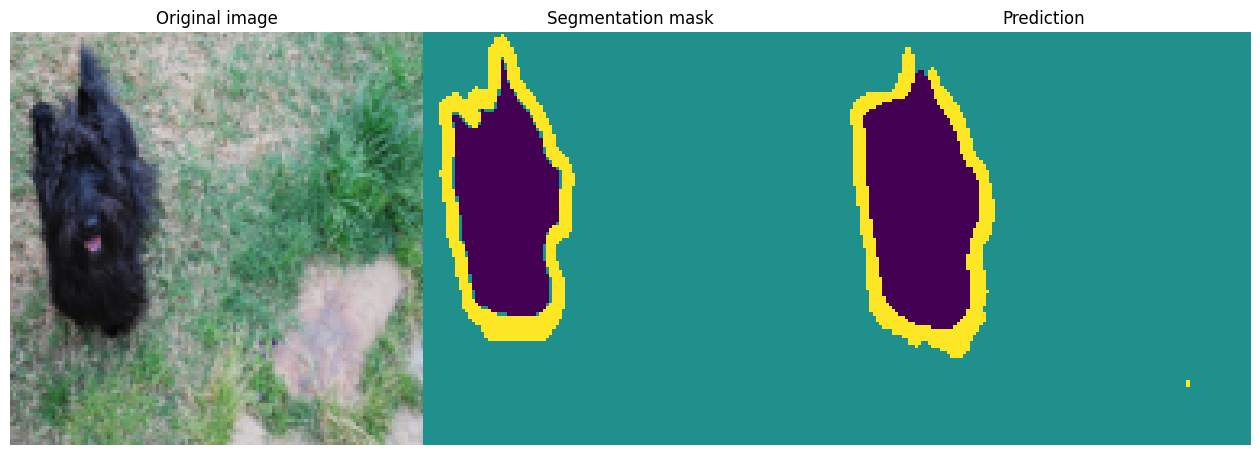

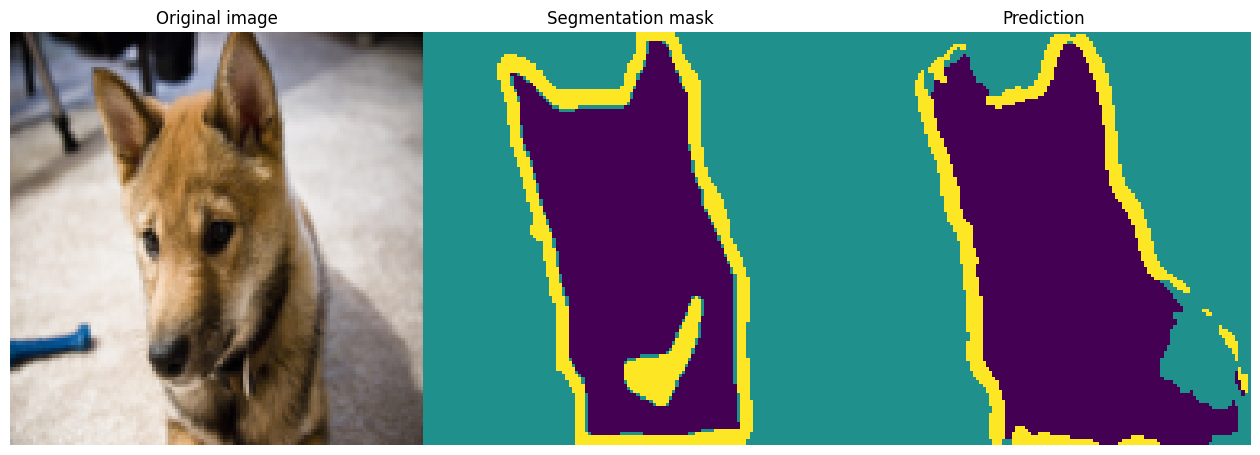

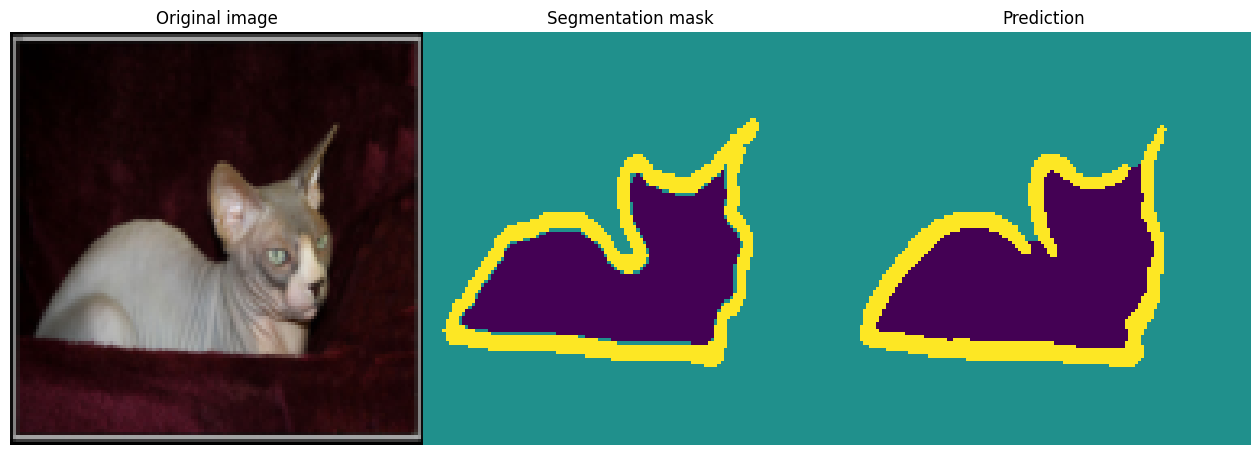

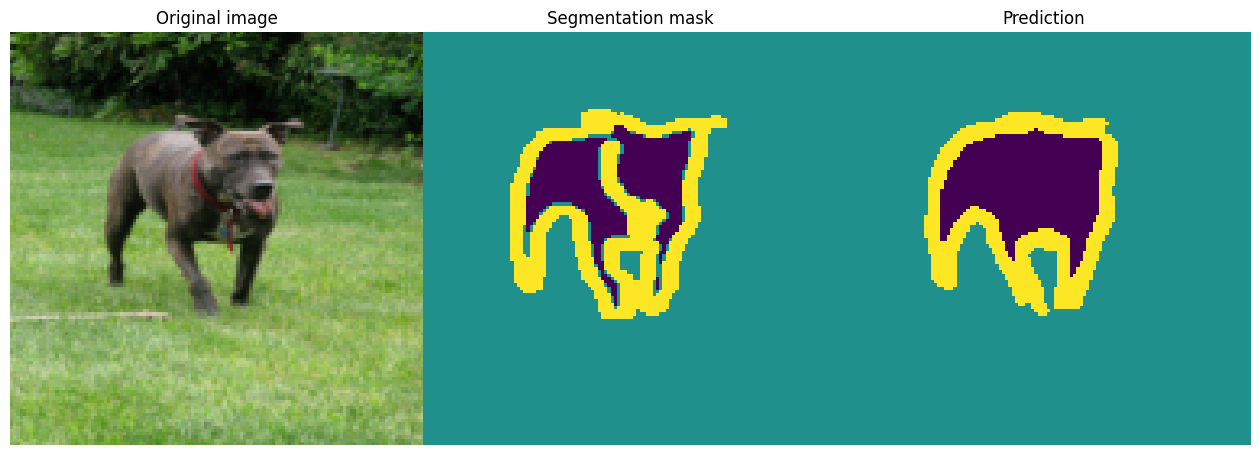

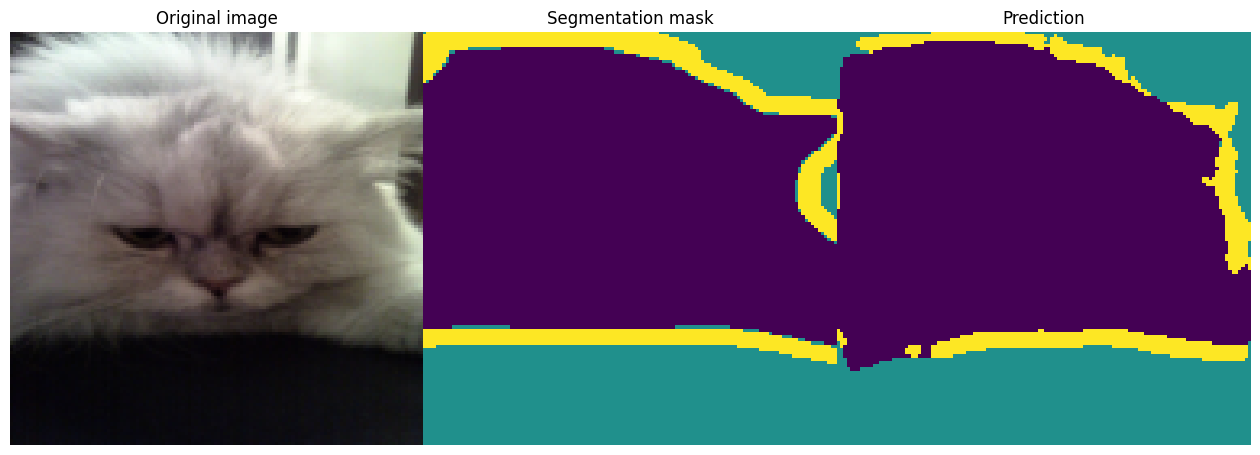

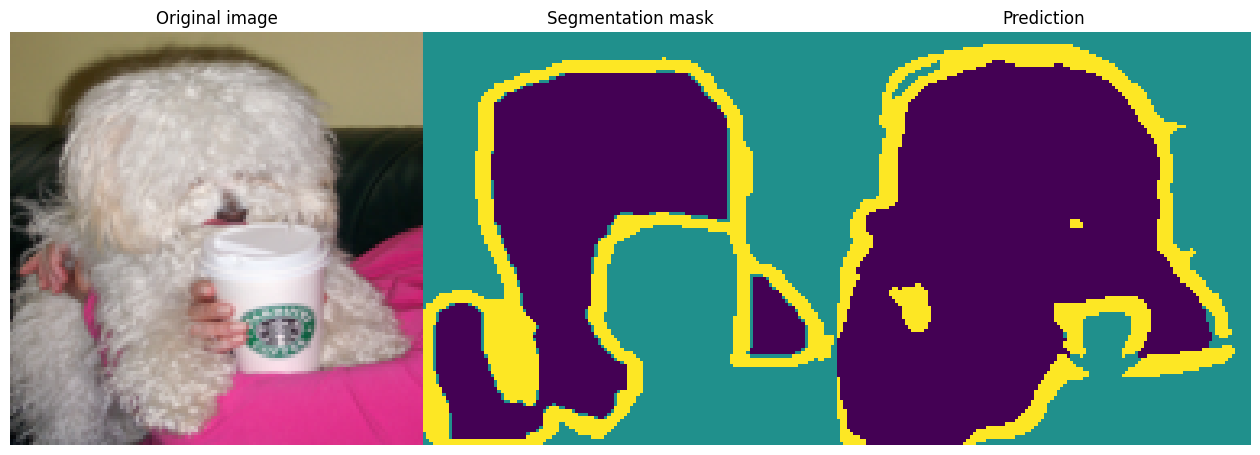

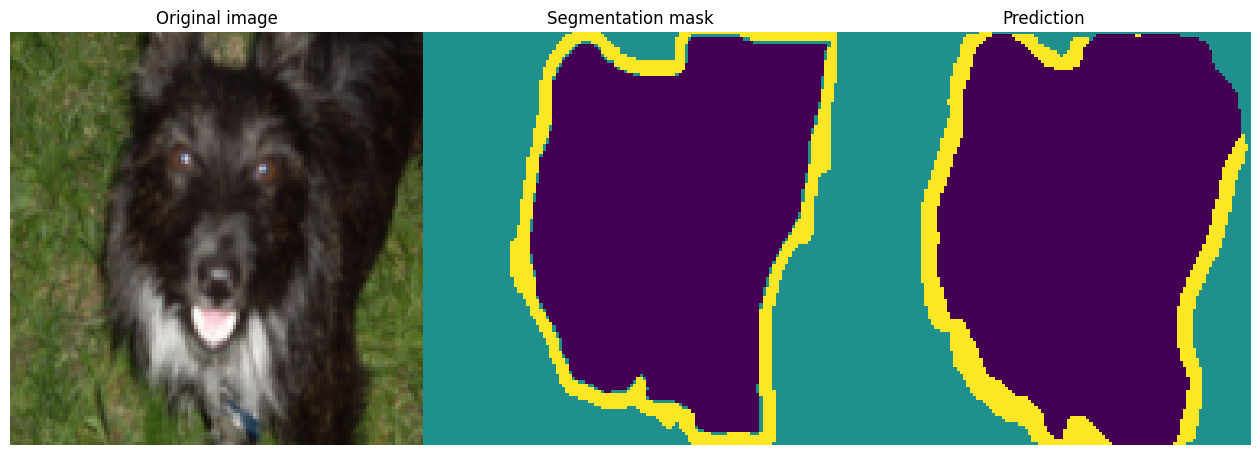

In [66]:
visualize(model, next(iter(train_loader)))